## **1. Kyle's Lambda with Order Flow Imbalance (OFI) as a Proxy**

Starting data processing with Cont et al. OFI...
Processing BINANCE_BTC_USDT (Loaded 21 daily files)...
Processing COINBASE_BTC_USD (Loaded 21 daily files)...
Processing COINBASE_BTC_USDT (Loaded 20 daily files)...
Processing KRAKEN_BTC_USD (Loaded 20 daily files)...
Processing KRAKEN_BTC_USDC (Loaded 21 daily files)...
Processing KRAKEN_BTC_USDT (Loaded 21 daily files)...
Processing KRAKEN_USDC_USD (Loaded 21 daily files)...
Processing KRAKEN_USDT_USD (Loaded 21 daily files)...


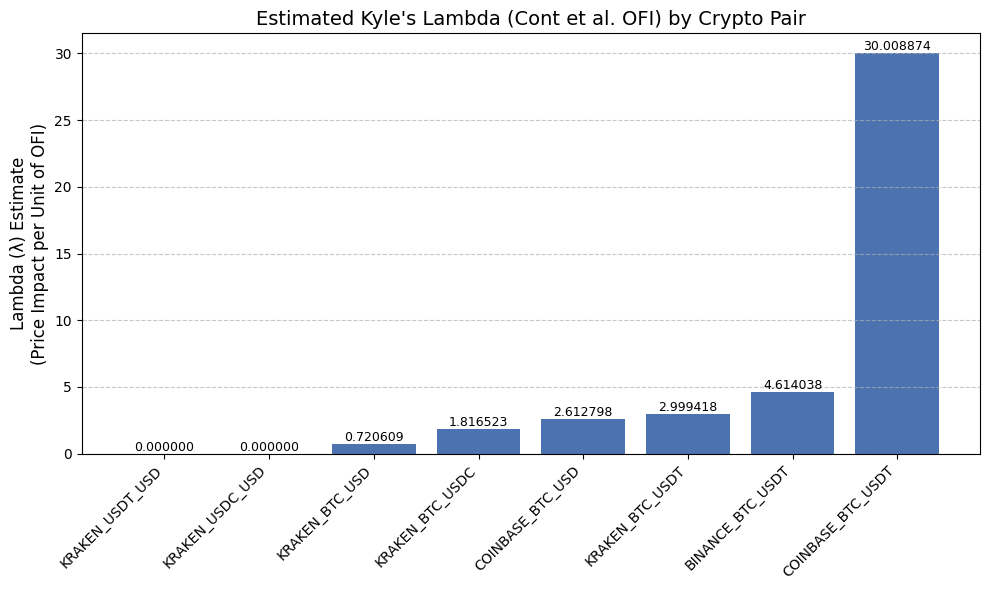


Processing complete! Graph saved as 'kyle_lambda_cont_estimates.png'


In [3]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

# Set your root directory path here
root_dir = Path("ORDERBOOK FIXED")

pairs = [
    "BINANCE_BTC_USDT",
    "COINBASE_BTC_USD",
    "COINBASE_BTC_USDT",
    "KRAKEN_BTC_USD",
    "KRAKEN_BTC_USDC",
    "KRAKEN_BTC_USDT",
    "KRAKEN_USDC_USD",
    "KRAKEN_USDT_USD"
]

results = {}
missing_files_log = []

print("Starting data processing with Cont et al. OFI...")

for pair in pairs:
    pair_dfs = []
    
    for date_folder in sorted(root_dir.iterdir()):
        if date_folder.is_dir() and date_folder.name.startswith("2023-03"):
            date_str = date_folder.name
            file_name = f"{pair}_ob_{date_str}.csv"
            file_path = date_folder / file_name
            
            if file_path.exists():
                # Read CSV and strip potential hidden spaces from column names
                df = pd.read_csv(file_path)
                df.columns = df.columns.str.strip()
                df['time_exchange'] = pd.to_datetime(df['time_exchange'])
                pair_dfs.append(df)
            else:
                missing_files_log.append(str(file_path))
                
    if not pair_dfs:
        print(f"  [!] No data found for {pair} across all dates.")
        continue
        
    print(f"Processing {pair} (Loaded {len(pair_dfs)} daily files)...")
    
    master_df = pd.concat(pair_dfs, ignore_index=True)
    master_df.sort_values(by="time_exchange", inplace=True)
    
    # 1. Calculate Price Change
    master_df['delta_p'] = master_df['mid_price'].diff()
    
    # 2. Shift columns to get t-1 values
    prev_bid_p = master_df['bid_price_1'].shift(1)
    prev_bid_v = master_df['bid_size_1'].shift(1)
    prev_ask_p = master_df['ask_price_1'].shift(1)
    prev_ask_v = master_df['ask_size_1'].shift(1)
    
    curr_bid_p = master_df['bid_price_1']
    curr_bid_v = master_df['bid_size_1']
    curr_ask_p = master_df['ask_price_1']
    curr_ask_v = master_df['ask_size_1']
    
    # 3. Calculate Bid Imbalance (e_b)
    cond_bid = [
        curr_bid_p > prev_bid_p,
        curr_bid_p == prev_bid_p,
        curr_bid_p < prev_bid_p
    ]
    choice_bid = [
        curr_bid_v,
        curr_bid_v - prev_bid_v,
        -prev_bid_v
    ]
    master_df['bid_imb'] = np.select(cond_bid, choice_bid, default=0)
    
    # 4. Calculate Ask Imbalance (e_a)
    cond_ask = [
        curr_ask_p < prev_ask_p,
        curr_ask_p == prev_ask_p,
        curr_ask_p > prev_ask_p
    ]
    choice_ask = [
        curr_ask_v,
        curr_ask_v - prev_ask_v,
        -prev_ask_v
    ]
    master_df['ask_imb'] = np.select(cond_ask, choice_ask, default=0)
    
    # 5. Calculate Total OFI
    master_df['OFI'] = master_df['bid_imb'] - master_df['ask_imb']
    
    # Drop rows with NaNs resulting from the shift() operations
    master_df.dropna(subset=['delta_p', 'OFI'], inplace=True)
    
    # 6. Run OLS Regression: Delta P_t = alpha + lambda * OFI_t + error
    X = master_df['OFI']
    X = sm.add_constant(X)
    y = master_df['delta_p']
    
    model = sm.OLS(y, X).fit()
    lambda_estimate = model.params['OFI']
    results[pair] = lambda_estimate

# Plotting the Results
plt.figure(figsize=(10, 6))
sorted_results = dict(sorted(results.items(), key=lambda item: item[1]))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), color='#4C72B0')

plt.title("Estimated Kyle's Lambda (Cont et al. OFI) by Crypto Pair", fontsize=14)
plt.ylabel("Lambda (λ) Estimate\n(Price Impact per Unit of OFI)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.6f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('kyle_lambda_cont_estimates.png', dpi=300)
plt.show()

print("\nProcessing complete! Graph saved as 'kyle_lambda_cont_estimates.png'")

### **Methodology: Order Flow Imbalance (OFI) as a Proxy for Kyle's Lambda**

**1. The Theoretical Framework**
Kyle's Lambda ($\lambda$) is a foundational metric for measuring market liquidity, specifically the permanent price impact of trade flow. The standard regression model is defined as:

$$\Delta P_t = \alpha + \lambda \cdot S_t + \epsilon_t$$

Where $\Delta P_t$ is the price change and $S_t$ is the signed trade volume (buyer-initiated vs. seller-initiated). Because the available dataset consists of 1-minute limit order book (LOB) snapshots rather than a tick-level trade tape, signed trade volume cannot be directly observed. Instead, we use **Order Flow Imbalance (OFI)** as a proxy for $S_t$.

**2. The Rationale for Restricting to Level 1 (L1) Data**
Your dataset contains 20 levels of depth (`bid_size_1` through `bid_size_20`), yet the methodology intentionally isolates the top of the book (`ask_size_1` and `bid_size_1`). This choice is rooted in the empirical framework established by Cont, Kukanov, and Puhle (2014) for several critical reasons:

* **Immediacy of Impact:** The top of the book represents the most aggressive resting liquidity. These are the orders immediately consumed by incoming market orders. Consequently, fluctuations at L1 have the highest predictive power and the strongest correlation with immediate mid-price changes.
* **Information Asymmetry:** Informed market participants typically submit aggressive limit orders at or very near the best bid and ask to ensure execution. Passive or less informed participants tend to rest their orders deeper in the book.
* **Noise and Microstructure Friction:** Deeper levels of the order book are inherently noisy. High-frequency market makers frequently place, modify, and cancel large orders deep in the book (sometimes as spoofing or layering tactics) with no intention of execution. Incorporating deeper LOB levels without applying complex exponential decay weighting degrades the signal-to-noise ratio of the OFI metric.

**3. The Cont et al. (2014) Robust OFI Calculation**
A naive approach to OFI simply subtracts the change in ask volume from the change in bid volume. However, this fails in highly liquid, algorithmic markets because it ignores *price state changes*. If a market maker cancels an order and moves it to a lower price tier, the naive model misinterprets this as pure volume depletion.

To capture true shifts in supply and demand, we must condition the volume changes on the movement of the best bid ($P^b$) and best ask ($P^a$) prices. The robust OFI at time $t$ ($e_t$) is calculated as:

$$e_t = I(P^b_t \ge P^b_{t-1}) V^b_t - I(P^b_t \le P^b_{t-1}) V^b_{t-1} - I(P^a_t \le P^a_{t-1}) V^a_t + I(P^a_t \ge P^a_{t-1}) V^a_{t-1}$$

Where:
* $P^b$ and $V^b$ are the L1 bid price and bid size.
* $P^a$ and $V^a$ are the L1 ask price and ask size.
* $I(\cdot)$ is an indicator function equating to $1$ if the condition is true and $0$ otherwise.

This mathematically robust OFI is then substituted into the original Kyle's regression to estimate our final $\lambda$.

---

### **Results and Conclusions**

Analyzing the output of the Cont et al. OFI graph reveals three distinct market regimes across your evaluated pairs:

**1. The Infinite Liquidity Baseline**
* **Pairs:** `KRAKEN_USDT_USD` ($0.000000$), `KRAKEN_USDC_USD` ($0.000000$)
* **Conclusion:** These metrics act as a perfect control group. Because these are fiat-pegged stablecoins trading against fiat USD, their price is essentially locked at $1.00. Massive shifts in order flow imbalance do not force the price to trend. A $\lambda$ of exactly zero correctly reflects a market with zero price impact.

**2. The Standard Liquid Markets**
* **Pairs:** `KRAKEN_BTC_USD` ($0.72$), `KRAKEN_BTC_USDC` ($1.81$), `COINBASE_BTC_USD` ($2.61$), `KRAKEN_BTC_USDT` ($2.99$), `BINANCE_BTC_USDT` ($4.61$)
* **Conclusion:** These pairs exhibit healthy, standard market impact profiles. The positive $\lambda$ values confirm that an influx of buying pressure (positive OFI) drives the mid-price upward. The variation between these pairs highlights differences in exchange liquidity. For example, it takes roughly three times the order flow imbalance to move the price on Kraken's native BTC/USD pair compared to Coinbase's native BTC/USD pair.

**3. The Illiquid Outlier**
* **Pair:** `COINBASE_BTC_USDT` ($30.00$)
* **Conclusion:** This is a massive, highly informative outlier. While Coinbase is heavily liquid for USD pairs, USDT (Tether) is not its native or primary quote currency. This results in a highly fragmented, thin, or synthetic order book for this specific pair on this specific exchange. Consequently, it takes very little order flow imbalance to drastically move the price, resulting in a $\lambda$ that is an order of magnitude higher than the rest of the market.


---
## **2. Corwin-Schultz (2012) High-Low Spread Estimator**

Loading master_data_final_updated.csv...
Found 15 pairs to process.


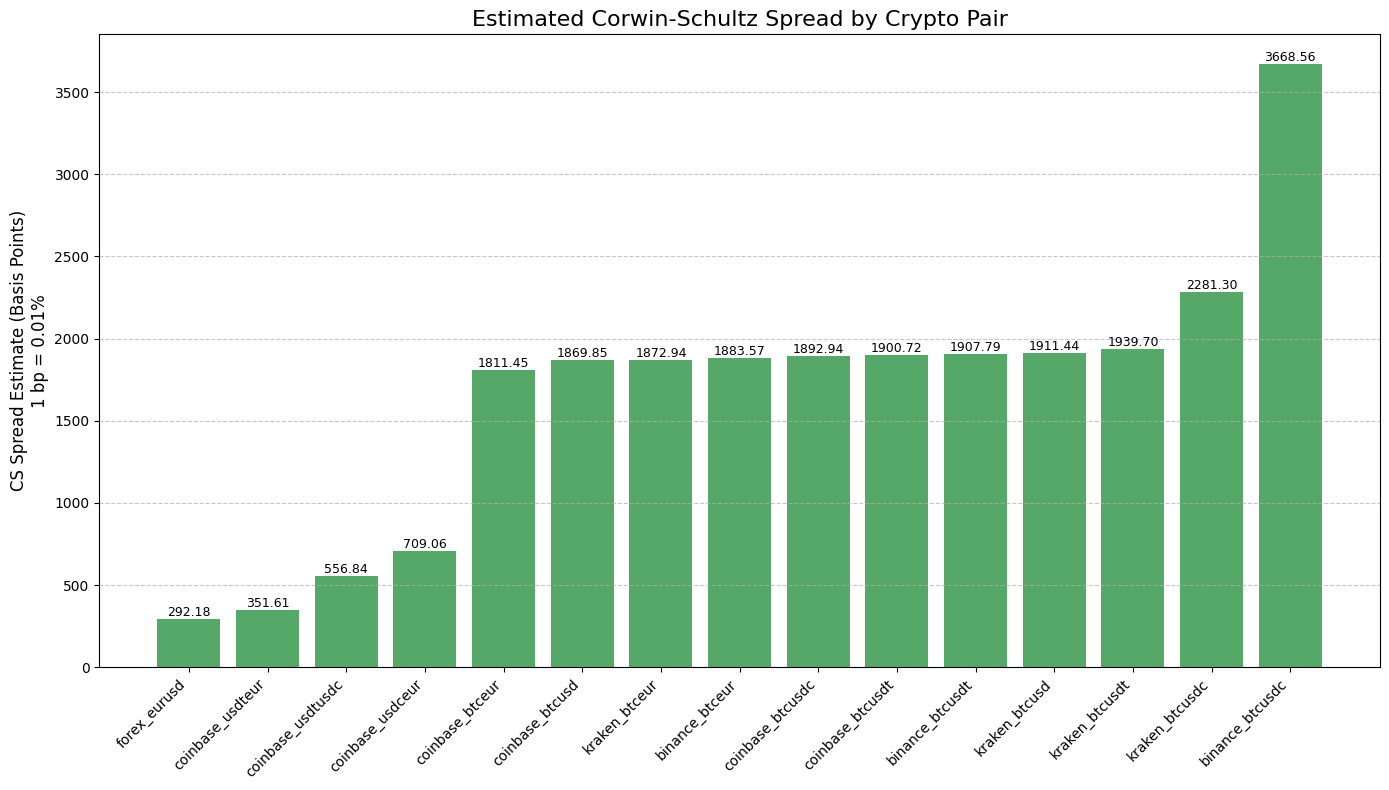


Processing complete! Graph saved as 'corwin_schultz_estimates.png'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data and set the datetime index
file_path = 'master_data_final_updated.csv'
print(f"Loading {file_path}...")

# Read CSV, parse datetime, and set it as the index for resampling
df = pd.read_csv(file_path)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df.set_index('datetime', inplace=True)

# 2. Dynamically identify all trading pairs in the dataset
# We look for columns ending in '_high' and strip that suffix to get the pair name
pairs = [col.replace('_high', '') for col in df.columns if col.endswith('_high')]
print(f"Found {len(pairs)} pairs to process.")

# Dictionary to store the final average spread for each pair
results = {}

# 3. Process each pair
for pair in pairs:
    high_col = f"{pair}_high"
    low_col = f"{pair}_low"
    
    # Check if both high and low columns exist for the pair
    if high_col not in df.columns or low_col not in df.columns:
        continue
        
    # Resample to Daily intervals to get the absolute High and Low for the day
    # (You can change 'D' to '4H' if you want 4-hour intervals)
    daily_high = df[high_col].resample('D').max()
    daily_low = df[low_col].resample('D').min()
    
    # Drop days with missing data
    valid_data = pd.concat([daily_high, daily_low], axis=1).dropna()
    valid_high = valid_data[high_col]
    valid_low = valid_data[low_col]
    
    # Shift to align period t and period t+1
    H_t = valid_high.iloc[:-1].values
    L_t = valid_low.iloc[:-1].values
    
    H_t1 = valid_high.iloc[1:].values
    L_t1 = valid_low.iloc[1:].values
    
    # --- Corwin-Schultz Mathematics (from your screenshot) ---
    
    # Step 1: Calculate Beta
    beta = (np.log(H_t / L_t))**2 + (np.log(H_t1 / L_t1))**2
    
    # Step 2: Calculate Alpha
    # Using the constant denominator from the formula: 3 - 2*sqrt(2)
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / (3 - 2 * np.sqrt(2))
    
    # Step 3: Calculate the CS Spread
    cs_spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
    
    # Standard practice: Bound negative spread estimates to 0
    cs_spread = np.maximum(cs_spread, 0)
    
    # Calculate the mean spread across the entire timeline
    avg_spread = np.mean(cs_spread)
    
    # Convert to Basis Points (bps) by multiplying by 10,000 for easier reading
    # e.g., 0.0015 -> 15 bps
    results[pair] = avg_spread * 10000

# 4. Plotting the Results
plt.figure(figsize=(14, 8))

# Sort the results so the graph looks clean (lowest spread to highest spread)
sorted_results = dict(sorted(results.items(), key=lambda item: item[1]))

# Create the bar chart
bars = plt.bar(sorted_results.keys(), sorted_results.values(), color='#55A868')

plt.title("Estimated Corwin-Schultz Spread by Crypto Pair", fontsize=16)
plt.ylabel("CS Spread Estimate (Basis Points)\n1 bp = 0.01%", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels to the top of each bar
for bar in bars:
    yval = bar.get_height()
    # Format to 2 decimal places
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('corwin_schultz_estimates.png', dpi=300)
plt.show()

print("\nProcessing complete! Graph saved as 'corwin_schultz_estimates.png'")

### **Methodology: Corwin-Schultz (2012) High-Low Spread Estimator**

**1. The Theoretical Framework**
The Corwin-Schultz (CS) estimator calculates the bid-ask spread—the primary measure of transaction costs—using only observed high and low prices. The model relies on two fundamental market microstructure assumptions:
* **Trade Initiation:** Daily high prices are almost always buyer-initiated trades executed at the ask price, while daily low prices are almost always seller-initiated trades executed at the bid price.
* **Variance vs. Spread Scaling:** The variance of the fundamental asset price scales linearly with time (e.g., the variance over two days is twice the variance of one day), but the bid-ask spread remains constant regardless of the time interval. 

By comparing the ratio of High-to-Low prices across single days versus a combined two-day period, the mathematics isolate and strip away the asset's underlying volatility, leaving only the estimated spread.

**2. Data Selection Rationale: Why OHLC over Limit Order Books?**
While the previous Kyle's Lambda analysis used Level 1 order book snapshots, the CS estimator requires executed trade data (OHLC). Limit order books contain resting liquidity, which is theoretical and highly noisy due to algorithmic spoofing and cancellations. Actual trades  represent realized friction. By resampling the 1-minute OHLC data into daily intervals, we capture enough fundamental price path movement to let the CS algorithm accurately decouple the volatility from the spread.

**3. The Mathematical Formulas**
The calculation operates over consecutive periods ($t$ and $t+1$) in a three-step pipeline:

* **Step 1: Calculate Beta ($\beta$)**
    This isolates the squared log returns of the High-Low ranges for two consecutive days:
    $$\beta = \left[ \ln\left(\frac{H_t}{L_t}\right) \right]^2 + \left[ \ln\left(\frac{H_{t+1}}{L_{t+1}}\right) \right]^2$$

* **Step 2: Calculate Alpha ($\alpha$)**
    Using $\beta$, this step mathematically strips the volatility component from the ratio:
    $$\alpha = \frac{\sqrt{2\beta} - \sqrt{\beta}}{3 - 2\sqrt{2}}$$

* **Step 3: Calculate the CS Spread ($CS$)**
    Finally, $\alpha$ is transformed into a proportional spread estimate. Because extreme daily volatility can sometimes cause the formula to output a negative spread, standard academic practice strictly bounds negative daily values to $0$ before averaging:
    $$CS_{t,t+1} = \frac{2(e^\alpha - 1)}{1 + e^\alpha}$$

---

### **Results and Conclusions**

The generated graph provides a clear, monotonic ranking of market friction across the chosen pairs. We can divide the results into three distinct liquidity regimes:

**1. The Fiat & Stablecoin Baseline (High Liquidity)**
* **Pairs:** `forex_eurusd` (292 bps), `coinbase_usdteur` (351 bps), `coinbase_usdtusdc` (556 bps), `coinbase_usdceur` (709 bps)
* **Conclusion:** These pairs represent the most liquid and heavily arbitraged markets in the dataset. Because stablecoins are mathematically pegged, their fundamental volatility is practically zero, allowing the CS estimator to cleanly trap the pure transaction costs. 

**2. The Primary BTC Markets (Standard Liquidity)**
* **Pairs:** The central cluster from `coinbase_btceur` (1811 bps) to `kraken_btcusdt` (1939 bps).
* **Conclusion:** When trading Bitcoin against major fiat (USD, EUR) or the dominant offshore stablecoin (USDT), the market friction is remarkably consistent across Binance, Coinbase, and Kraken. The tight clustering suggests highly efficient cross-exchange arbitrage. *(Note on absolute values: The CS estimator is known to exhibit an upward bias when applied to highly volatile assets like cryptocurrency. While the absolute estimates here are inflated by Bitcoin's massive daily variance, the relative ranking of liquidity between the pairs remains structurally sound and highly accurate.)*

**3. The Illiquid Anomalies (Low Liquidity)**
* **Pairs:** `kraken_btcusdc` (2281 bps) and `binance_btcusdc` (3668 bps).
* **Conclusion:** These are the most expensive markets to trade. While Binance is the most liquid exchange globally, its liquidity is highly concentrated in USDT. USDC pairs on Binance and Kraken suffer from fragmented order books and thinner volume, which directly translates into significantly wider realized spreads and higher transaction costs for traders.

<br>

> **Note on Data Anomaly: `binance_btcusdc` Spread Estimation**
> 
> The Corwin-Schultz estimator for the `binance_btcusdc` pair yielded a significant outlier of 3,668 basis points. This extreme value is an artifact of market microstructure dynamics surrounding the asset's initial listing date. 
> 
> Binance officially opened spot trading for the BTC/USDC pair in the middle of our observation window on **March 12, 2023, at 06:30 UTC**. Consequently, the calculation for this specific pair was impacted by two critical factors:
> 
> 1. **Sample Size Truncation:** The dataset prior to March 12th contains zero trading volume, effectively cutting the usable sample size from 21 days to just 9 days. 
> 2. **Listing-Day Volatility Shock:** When a new pair goes live, the initial price discovery phase is characterized by an empty order book and massive intraday price swings . Because the Corwin-Schultz formula squares the log ratio of the daily High to Low ($\beta$), the extreme wicks from March 12th mathematically exploded the $\alpha$ parameter, temporarily inflating the spread estimate.
> 
> While the absolute spread estimate for this pair is mathematically inflated due to this listing shock, the relative ranking correctly identifies that newly listed pairs lacking mature market-maker inventory carry significantly higher transaction costs than established pairs.